In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import vis

DATA_PATH = '../../E-COMP/Dataset/Post Optimization Dataset/'

self = vis.Visualizer(os.path.join(DATA_PATH, '9O-5V.json'))

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


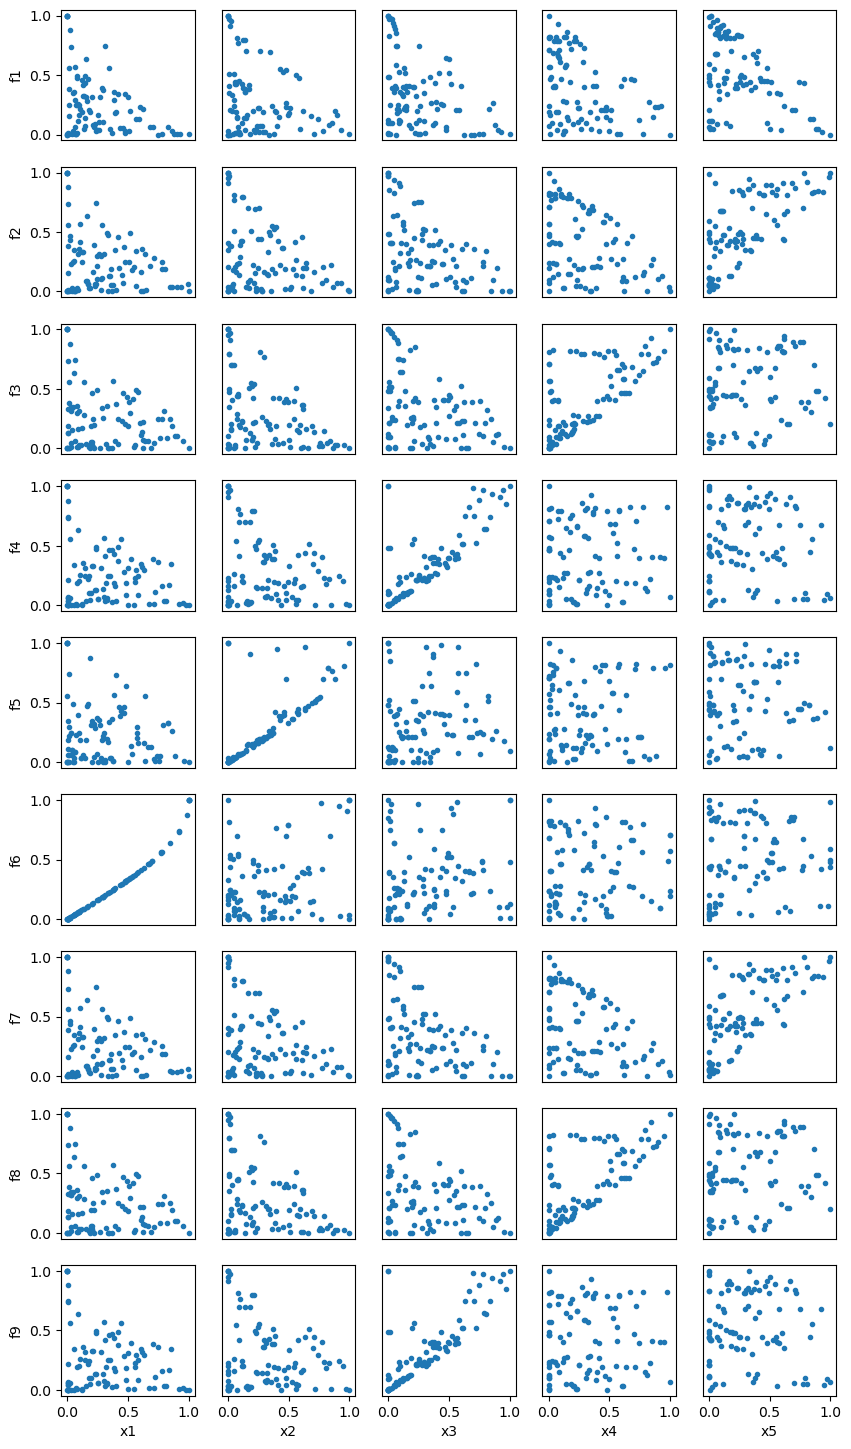

In [2]:
self.show_splom()

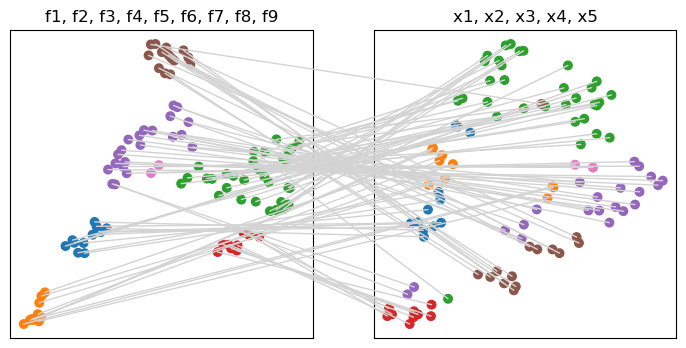

In [3]:
self.show_parallel_embeddings(
    scatter_kwargs=dict(s=150),
    connect_cluster='all',
)

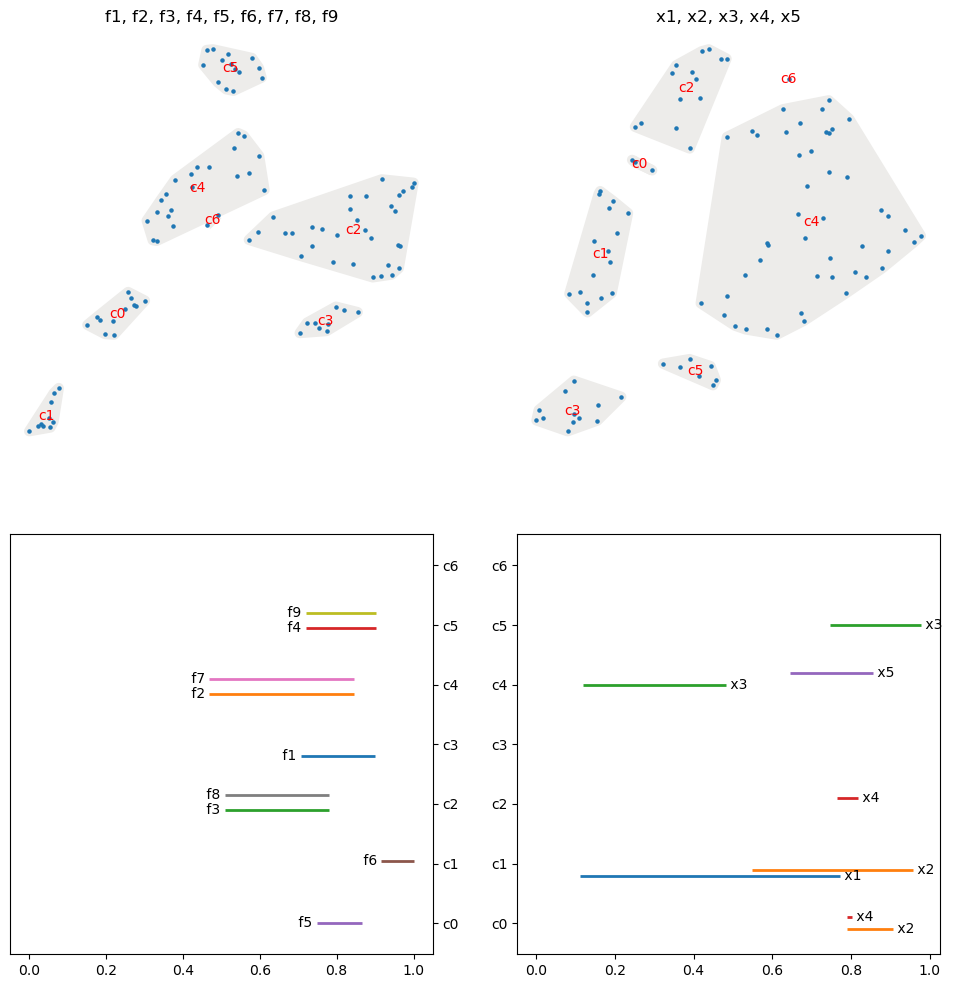

In [4]:
from importlib import reload
import os
import vis

DATA_PATH = '../../E-COMP/Dataset/Post Optimization Dataset/'

reload(vis)
self = vis.Visualizer(os.path.join(DATA_PATH, '9O-5V.json'))
self.show_joint_clustering_with_embedding()

In [5]:
from importlib import reload; reload(vis)

self = vis.Visualizer(os.path.join(DATA_PATH, '9O-5V.json'))

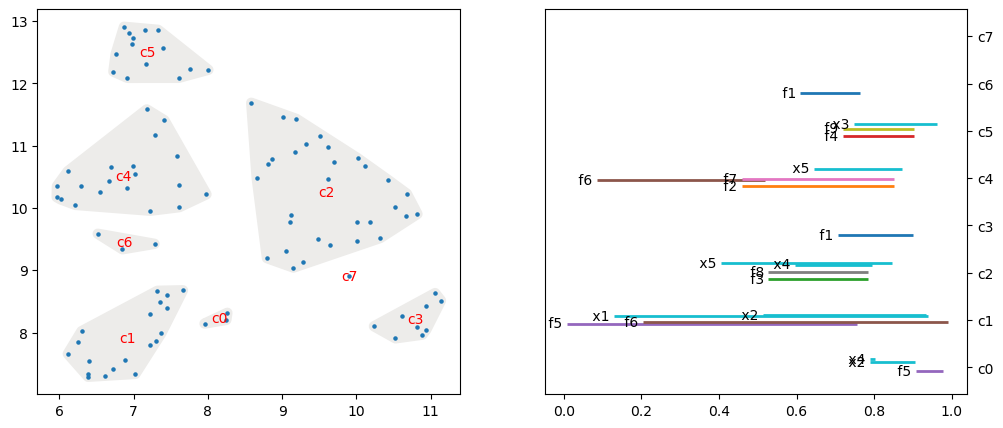

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
vis.get_cluster_hulls(self.joint_xy, self.y_joint, ax=plt.subplot(121))
vis.explain_cluster(self.X_joint, self.y_joint, ax=plt.subplot(122));

In [7]:
# Assumption: Simpson paradox is happening; different effects are happening at different regions of the decision space
# Solution: Cluster points based on decision variables; for each cluster determine correlation between decision and objective variables

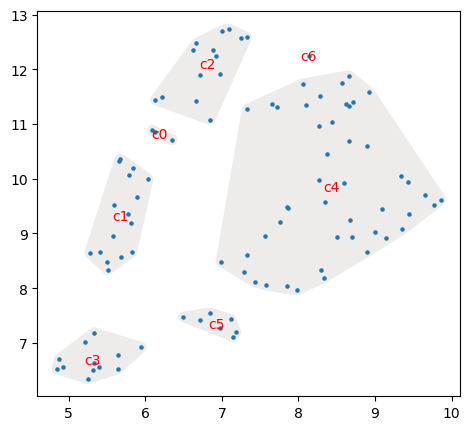

In [8]:
plt.figure(figsize=(12, 5))

vis.get_cluster_hulls(self.right_xy, self.y_right, ax=plt.subplot(121))


In [9]:
import pandas as pd

y = self.y_right
X = self.df

from scipy.stats import pearsonr

def pearsonr_safe(x, y, alpha=.05):
    if len(x) > 1:
        r, p = pearsonr(x, y)
        if p <= alpha:
            return r
    return None


def corr(df, index=None, columns=None):
    if index is None:
        index = df.columns
        
    if columns is None:
        columns = df.columns

    values = [
        [
            pearsonr_safe(df[i], df[c])
            for c in columns
        ]
        for i in index
    ]

    return pd.DataFrame(values, index=index, columns=columns)

correlations = X.groupby(y).apply(corr, index=self.dvars, columns=self.ovars)
correlations

/var/folders/s4/9x94zpfs62j4vkx8txp7_jx00000gn/T/ipykernel_54959/3712370071.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  correlations = X.groupby(y).apply(corr, index=self.dvars, columns=self.ovars)


f1        f2        f3        f4        f5        f6        f7  \
0 x1       NaN       NaN       NaN       NaN       NaN  1.000000       NaN   
  x2 -0.999381       NaN       NaN -0.999994       NaN       NaN       NaN   
  x3  0.999762       NaN  0.997410  0.999857       NaN       NaN       NaN   
  x4       NaN -0.999991       NaN       NaN       NaN       NaN -0.999991   
  x5       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
1 x1 -0.879548 -0.903982 -0.578559 -0.847011 -0.918392  0.978753 -0.903982   
  x2 -0.970919 -0.977205 -0.589082 -0.817374 -0.707522  0.895721 -0.977205   
  x3       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
  x4 -0.640707 -0.638835       NaN -0.750857 -0.823607  0.666649 -0.638835   
  x5       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
2 x1       NaN       NaN -0.916798       NaN  0.820752  0.998509       NaN   
  x2       NaN       NaN -0.745725       NaN  0.989972  0.826633       NaN   
  x3       NaN       NaN -0.873221  0.893841       NaN  0.718948       NaN   
  x4 -0.878058 -0.754701       NaN -0.584330       NaN       NaN -0.754701   
  x5       NaN  0.630052       NaN       NaN       NaN       NaN  0.630052   
3 x1 -0.790503       NaN       NaN       NaN       NaN  0.999979       NaN   
  x2       NaN       NaN       NaN       NaN  0.998993       NaN       NaN   
  x3       NaN       NaN       NaN  0.998281       NaN       NaN       NaN   
  x4 -0.697770       NaN  0.984560       NaN       NaN  0.687803       NaN   
  x5       NaN  0.988162       NaN       NaN       NaN       NaN  0.988162   
4 x1       NaN -0.439906 -0.314525       NaN -0.395014  0.973051 -0.439906   
  x2       NaN       NaN       NaN  0.324307  0.991632 -0.296125       NaN   
  x3       NaN -0.683882 -0.340319  0.914218  0.339723       NaN -0.683882   
  x4 -0.389682 -0.436980  0.782882       NaN  0.315832       NaN -0.436980   
  x5 -0.610682  0.475745  0.360936       NaN       NaN -0.505256  0.475745   
5 x1       NaN       NaN       NaN -0.766912       NaN  0.999783       NaN   
  x2       NaN       NaN       NaN -0.857121  0.989160       NaN       NaN   
  x3 -0.974136 -0.911973       NaN       NaN       NaN       NaN -0.911973   
  x4       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
  x5       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
6 x1       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
  x2       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
  x3       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
  x4       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
  x5       NaN       NaN       NaN       NaN       NaN       NaN       NaN   

            f8        f9  
0 x1       NaN       NaN  
  x2       NaN -0.999994  
  x3  0.997410  0.999857  
  x4       NaN       NaN  
  x5       NaN       NaN  
1 x1 -0.578559 -0.847011  
  x2 -0.589082 -0.817374  
  x3       NaN       NaN  
  x4       NaN -0.750857  
  x5       NaN       NaN  
2 x1 -0.916798       NaN  
  x2 -0.745725       NaN  
  x3 -0.873221  0.893841  
  x4       NaN -0.584330  
  x5       NaN       NaN  
3 x1       NaN       NaN  
  x2       NaN       NaN  
  x3       NaN  0.998281  
  x4  0.984560       NaN  
  x5       NaN       NaN  
4 x1 -0.314525       NaN  
  x2       NaN  0.324307  
  x3 -0.340319  0.914218  
  x4  0.782882       NaN  
  x5  0.360936       NaN  
5 x1       NaN -0.766912  
  x2       NaN -0.857121  
  x3       NaN       NaN  
  x4       NaN       NaN  
  x5       NaN       NaN  
6 x1       NaN       NaN  
  x2       NaN       NaN  
  x3       NaN       NaN  
  x4       NaN       NaN  
  x5       NaN       NaN

In [10]:
X = self.df[self.dvars]
Y = self.df[self.ovars]

points = []
clusters = []

for xi in X:
    clusters.append(self.pipe.fit_predict(X.drop(columns=[xi])))
    points.append(pd.DataFrame(self.pipe['proj'].embedding_, columns=['x', 'y']))

clusters = pd.DataFrame(clusters, index=X.columns).T
points = pd.concat(points, keys=X.columns)

# clusters = pd.DataFrame([
#     self.pipe.fit_predict(X.drop(columns=[xi]))
#     for xi in X
# ], index=X.columns).T

def pearsonr_safe(x, y, alpha=.05):
    if len(x) > 1 and x.nunique() > 1 and y.nunique() > 1:
        r, p = pearsonr(x, y)
        if p <= alpha:
            return r
    return None
    
def _corr(df, xi):
    return pd.Series({
        yi: pearsonr_safe(X.loc[df.index, xi], Y.loc[df.index, yi])
        for yi in Y
    })
    
corr = pd.concat([
    clusters.groupby(xi).apply(_corr, xi=xi, include_groups=False)
    for xi in clusters
], axis=0, keys=clusters.columns)

corr

f1        f2        f3        f4        f5        f6        f7  \
x1 0        NaN       NaN       NaN       NaN -0.973722  0.988048       NaN   
   1        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   2        NaN       NaN -0.547011 -0.553498       NaN  0.973582       NaN   
   3        NaN       NaN -0.895112       NaN  0.794390  0.999459       NaN   
   4  -0.877508       NaN       NaN       NaN       NaN  0.999979       NaN   
   5        NaN       NaN       NaN -0.956404       NaN  0.972642       NaN   
   6        NaN -0.898748       NaN       NaN       NaN  0.968768 -0.898748   
   7  -0.997424 -0.999509       NaN       NaN       NaN  1.000000 -0.999509   
   8        NaN       NaN       NaN       NaN       NaN  0.999933       NaN   
   9  -0.827514 -0.849995       NaN -0.650489 -0.737375  0.994890 -0.849995   
   10       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   11       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
x2 0  -0.742266 -0.687116 -0.936928 -0.609503  0.621162       NaN -0.687116   
   1  -0.485909 -0.667205 -0.859173       NaN       NaN       NaN -0.667205   
   2        NaN       NaN       NaN       NaN  0.998951       NaN       NaN   
   3        NaN       NaN       NaN       NaN  0.828906       NaN       NaN   
   4        NaN -0.659999       NaN       NaN  0.982758       NaN -0.659999   
   5        NaN       NaN       NaN -0.857121  0.989160       NaN       NaN   
   6  -0.901283 -0.943638       NaN       NaN  0.983966       NaN -0.943638   
   7   0.883874  0.888538  0.920322       NaN  0.990760       NaN  0.888538   
   8        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   9        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   10       NaN -0.891719       NaN       NaN  0.998239       NaN -0.891719   
   11       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
x3 0   0.999762       NaN  0.997410  0.999857       NaN       NaN       NaN   
   1        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   2        NaN       NaN -0.971774  0.988895       NaN       NaN       NaN   
   3  -0.869754 -0.599890 -0.707958  0.955180       NaN       NaN -0.599890   
   4  -0.577733 -0.574388       NaN  0.900654       NaN       NaN -0.574388   
   5        NaN -0.869656       NaN  0.994270       NaN  0.886703 -0.869656   
   6  -0.603812 -0.859567 -0.813919  0.954002       NaN -0.612947 -0.859567   
   7        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   8        NaN       NaN -0.999375       NaN       NaN       NaN       NaN   
   9        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   10       NaN       NaN       NaN  0.865704       NaN       NaN       NaN   
   11       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   12       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
x4 0  -0.662234 -0.671957       NaN -0.692227       NaN       NaN -0.671957   
   1  -0.646484       NaN  0.661360       NaN       NaN       NaN       NaN   
   2        NaN -0.562784  0.924512       NaN       NaN       NaN -0.562784   
   3  -0.476196 -0.758762  0.821307 -0.509437       NaN       NaN -0.758762   
   4        NaN -0.999943       NaN       NaN       NaN       NaN -0.999943   
   5        NaN       NaN  0.999990  0.999902       NaN       NaN       NaN   
x5 0        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   1        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   2  -0.575132  0.771273       NaN       NaN       NaN       NaN  0.771273   
   3  -0.871718  0.866526       NaN       NaN       NaN       NaN  0.866526   
   4        NaN  0.785836       NaN       NaN       NaN       NaN  0.785836   
   5  -0.971258       NaN       NaN -0.881152       NaN       NaN       NaN   
   6        NaN  0.737667       NaN       NaN       NaN       N

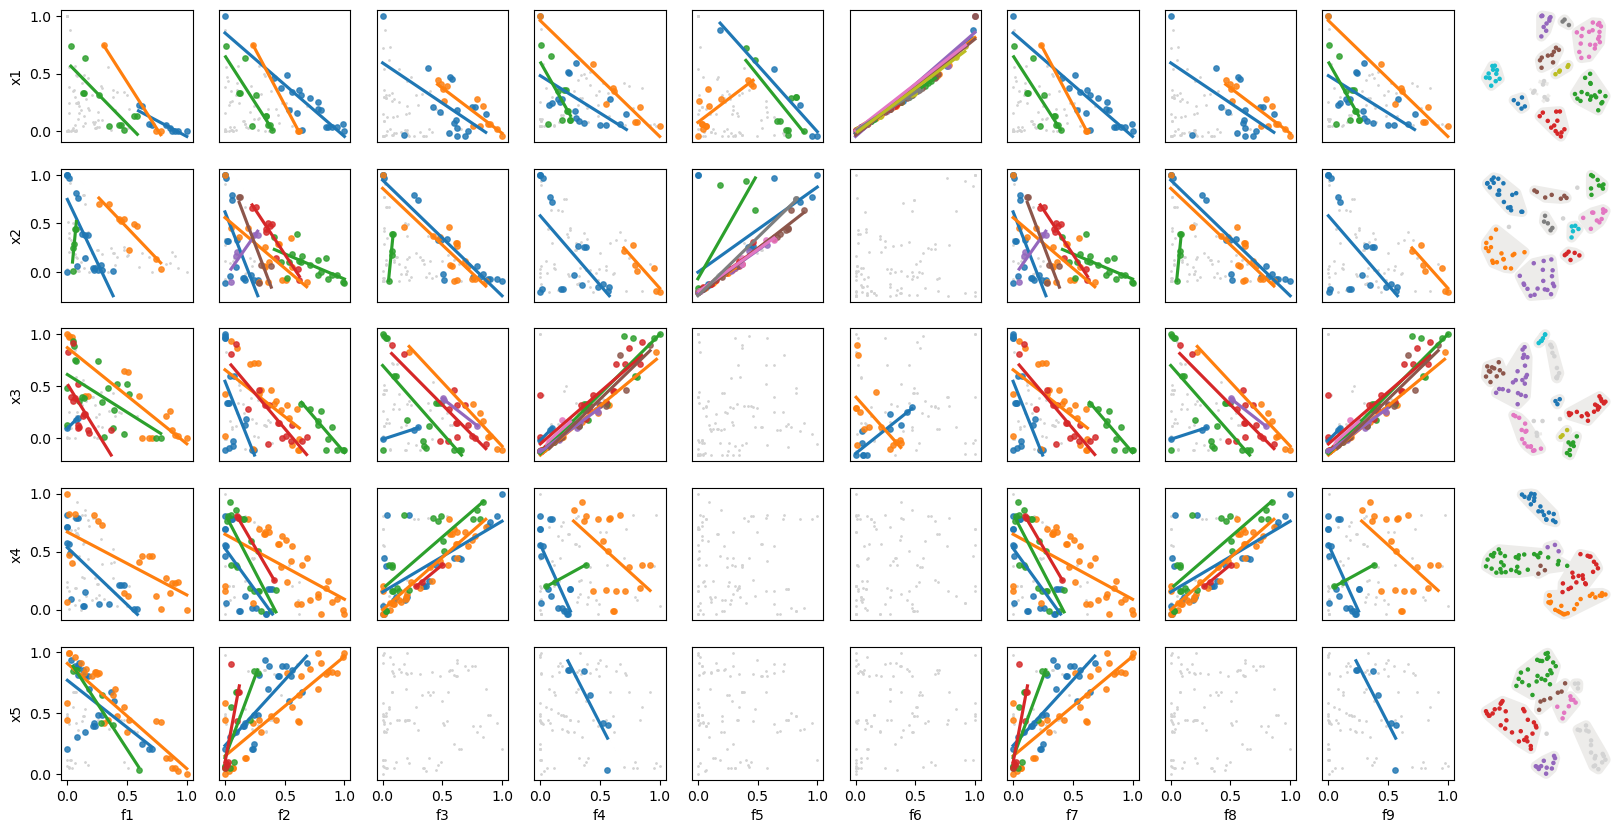

In [11]:
import numpy as np
import seaborn as sns
from matplotlib.colors import cnames, hex2color

marker_size_max = 15
marker_size_min = 1
s = 2
threshold = .5

rows = corr.index.get_level_values(0).unique()
cols = corr.columns

nrows = len(rows)
ncols = len(cols) + 1

default = hex2color(cnames['lightgray']) + (1,)

plt.figure(figsize=(s*ncols, s*nrows))
for i, r in enumerate(rows):
    y = clusters[r]
    color = plt.cm.tab10(y)
    
    for j, c in enumerate(cols):

        # optional: set clusters with p > alpha to lightgray

        ax = plt.subplot(nrows, ncols, i*ncols + j + 1)
        # plot using matplotlib
        # color_rc = color.copy()
        # color_rc[corr.loc[r, c].loc[y].isnull()] = default
        # size = (marker_size_max*corr.loc[r, c].loc[y].abs()).fillna(marker_size_min)
        # plt.scatter(Y[c], X[r], s=size, c=color_rc)

        # using seaborn
        ax.scatter(Y[c], X[r], s=1, c=np.atleast_2d(default))
        for k, dfk in pd.DataFrame({'xr': X[r], 'yc': Y[c]}).groupby(y):
            if abs(corr.loc[(r, k), c]) >= threshold:
                sns.regplot(
                    x='yc', y='xr', data=dfk,
                    ci=None,
                    scatter_kws=dict(s=15),
                    ax=ax
                )

            if i == nrows - 1:
                plt.xlabel(c)
            else:
                plt.xticks([], [])
                plt.xlabel('')
                
            if j == 0:
                plt.ylabel(r)
            else:
                plt.yticks([], [])
                plt.ylabel('')

    color_r = color.copy()
    color_r[corr.loc[r].isnull().all(axis=1).loc[y]] = default
    
    plt.subplot(nrows, ncols, i*ncols + j + 2)
    vis.get_cluster_hulls(
        points.loc[r].values,
        y,
        marker_color=color_r,
        with_labels=False
    )
    plt.axis('off')

# todo: fix colors

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='value', ylabel='variable'>

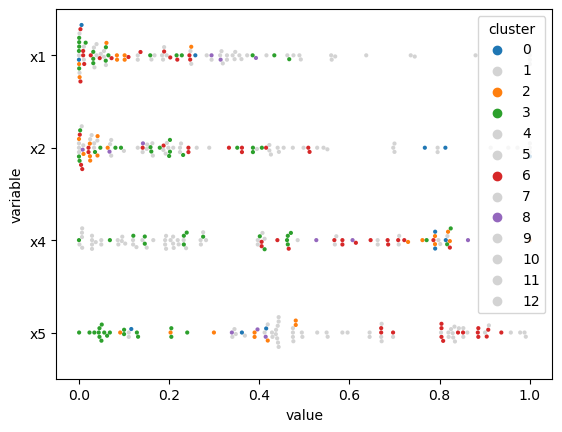

In [12]:
# todo: detailed explanation of a single cluster
# swarmplot

r = 'x3'
c = 'f3'

melted = X.drop(columns=[r])\
    .melt(ignore_index=False)
melted = melted.assign(cluster=clusters[r].loc[melted.index].values)

mask = corr.loc[r, c].abs() >= threshold

# squish the colors down to only use color for clusters whose correlation is > the threshold
color = plt.cm.tab10(mask.cumsum() - 1)
color[~mask] = default

sns.swarmplot(
    data=melted,
    x='value', y='variable', hue='cluster',
    size=3,
    palette=dict(zip(mask.index, color))
)

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1075

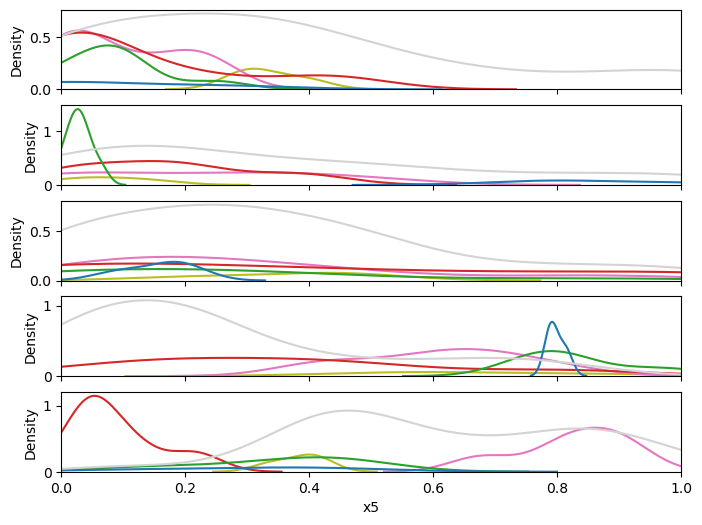

In [13]:
plt.figure(figsize=(8, 6))

n_rows = len(X.columns)

for i, xi in enumerate(X):
    mask = corr.loc[r, c].abs() >= threshold
    hue = mask.index.values.copy()
    hue[~mask] = -1
    
    palette = {
        i: plt.cm.tab10(i) if i >= 0 else default
        for i in hue
    }

    sns.kdeplot(
        X[[xi]].assign(hue=hue[clusters[r]]),
        x=xi,
        hue='hue',
        palette=palette,
        ax=plt.subplot(n_rows, 1, i + 1),
        legend=False
    )

    plt.xlim(0, 1)

    if i < n_rows - 1:
        ticks = plt.xticks()[0]
        plt.xticks(ticks, ['']*len(ticks))


In [14]:
# top_k = 10

# label = self.df[self.left]\
#     .rank(ascending=False)\
#     .idxmin(axis=1)

# rank = self.df[self.left]\
#     .rank(ascending=False)\
#     .min(axis=1)

# df = pd.DataFrame(self.right_xy, columns=['x', 'y'])\
#     .assign(label=label)


# sns.scatterplot(
#     df,
#     x='x',
#     y='y',
#     hue='label',
#     # size=100-rank,
#     size=rank <= top_k,
#     sizes={True: 35, False: 10}
# )
# plt.xlabel('')
# plt.ylabel('')
# plt.axis('equal');

,x1,x2,x3,x4,x5
f1 (i),-0.949232,-0.967980,-1.353868,-0.867923,-1.569466
f2 (i),-0.613043,-0.825989,-0.636695,-1.151047,2.196613
f3 (i),-0.345669,-1.105830,-0.608129,2.048235,-0.175758
f3 (ii),0.015400,-0.245631,-0.191650,0.256955,0.416799
f4 (i),-0.691211,-0.410749,1.766194,-0.004694,-1.383761
f4 (ii),-0.082448,-0.328434,1.548383,-0.072725,0.524586
f5 (i),-0.435637,1.260702,-0.391007,0.954782,-0.280028
f5 (ii),-0.541556,1.533906,-0.024449,-1.198692,0.082841
f6 (i),1.785225,1.709429,0.075732,0.101127,-0.051826
f6 (ii),1.561973,-0.721847,-0.263533,-0.455985,0.021736


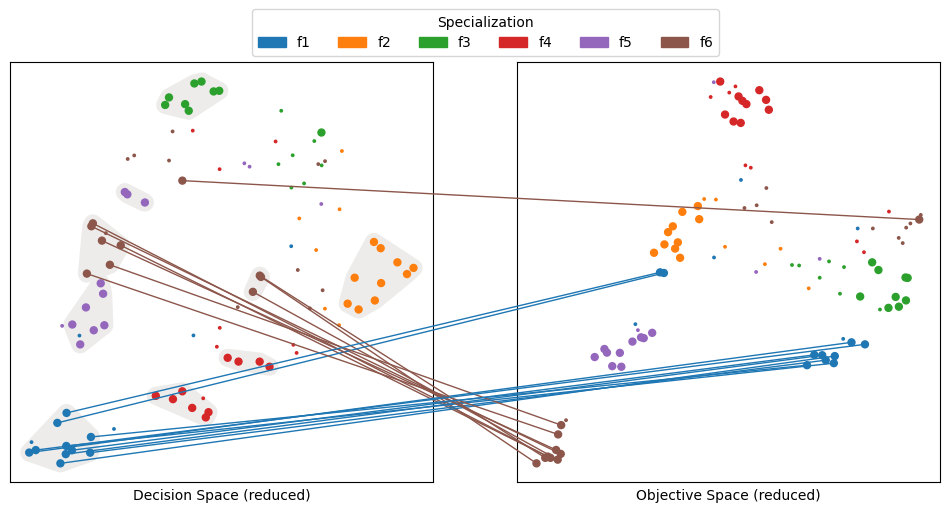

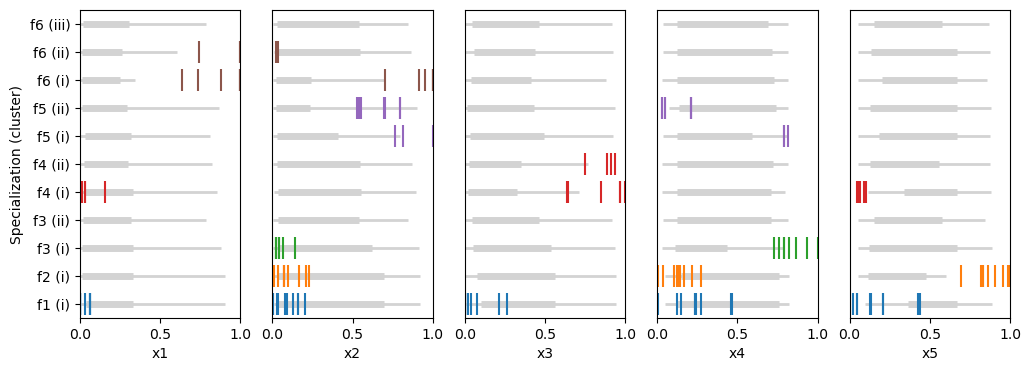

In [71]:
from importlib import reload; reload(vis)


lightgray = '#edecea'

self = vis.Visualizer(os.path.join(DATA_PATH, '9O-5V.json'))
self.show_specialization_clustering(selection={'f1', 'f6'})

mask = self.df_clustered.cluster.isnull()


labels, values = np.unique(self.df_clustered.label, return_inverse=True)
marker_color = plt.cm.tab10(values)

vis.explain_groups(
    self.df.loc[~mask, self.right],
    self.df_clustered.cluster[~mask],
    colors=marker_color[~mask]
)

In [69]:
self.df_clustered

,label,x,y,cluster
0,f5,6.089879,10.889526,f5 (i)
1,f6,5.652778,10.316249,f6 (i)
2,f6,6.036510,9.996901,f6 (i)
3,f3,6.998665,12.707960,f3 (i)
4,f1,5.399529,6.564753,f1 (i)
...,...,...,...,...
95,f2,9.356566,9.073102,f2 (i)
96,f4,6.494573,7.475823,f4 (i)
97,f2,8.704498,8.935654,None
98,f4,8.334207,8.194816,None


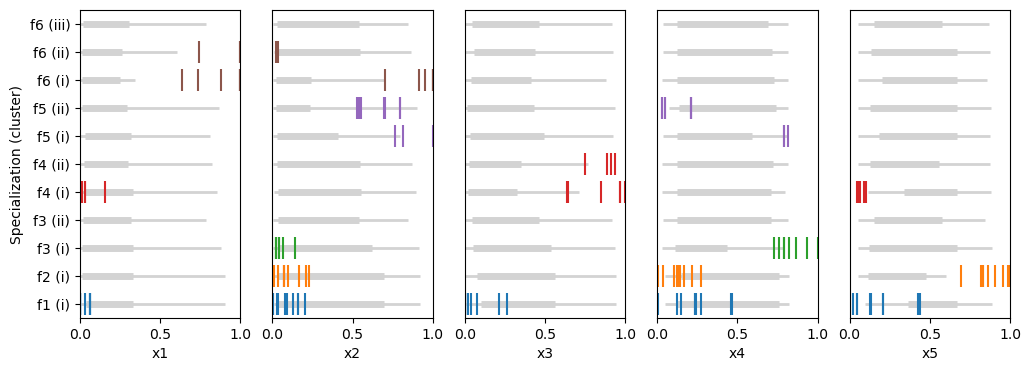

In [8]:
import vis
from importlib import reload; reload(vis)

mask = self.df_clustered.cluster.isnull()

coef = vis.explain_groups(
    self.df.loc[~mask, self.right],
    self.df_clustered.cluster[~mask],
    colors=marker_color[~mask]
)

/var/folders/s4/9x94zpfs62j4vkx8txp7_jx00000gn/T/ipykernel_20622/2672283462.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(points, [ymax]*len(points), c=c)
/var/folders/s4/9x94zpfs62j4vkx8txp7_jx00000gn/T/ipykernel_20622/2672283462.py:41: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(points, [0]*len(points), c=c)


([], [])

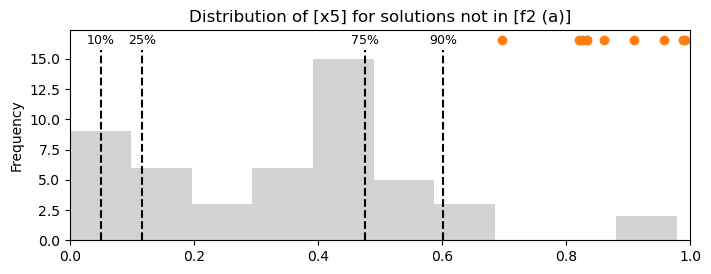

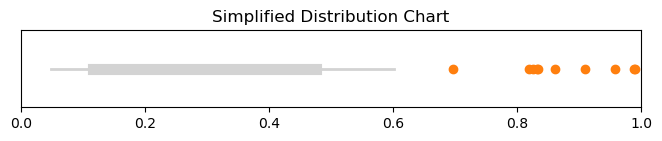

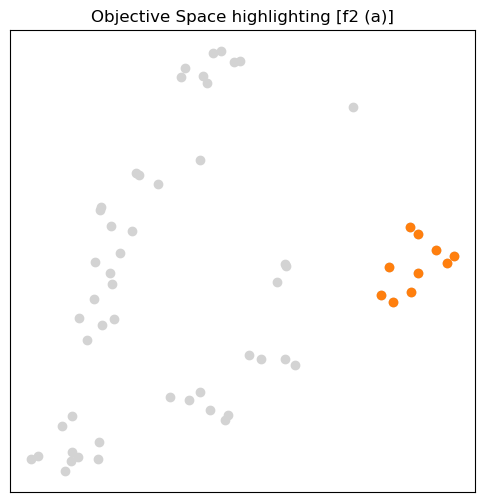

In [257]:
row = 'f2 (a)'
col = 'x5'

color_dict = {
    li: plt.cm.tab10(i)
    for i, li in enumerate(labels)
}

c = color_dict[row.split(' ')[0]]
percentiles=[.1, .25, .75, .90]
percentile_names = [f'{int(100*p)}%' for p in percentiles]

points = X.loc[y == row, col]
dist = X.loc[y != row, col]

plt.figure(figsize=(8,6))
plt.subplot(211)
plt.title(f'Distribution of [{col}] for solutions not in [{row}]')

dist.plot.hist(bins=10, color=default)

descr = dist.describe(percentiles=percentiles)
plt.vlines(
    descr[percentile_names],
    *plt.ylim(),
    color='black',
    linestyles='dashed'
)

for s, x in zip(percentile_names, descr[percentile_names]):
    _, ymax = plt.ylim()
    plt.annotate(s, (x, ymax), ha='center', va='center', fontsize=9)

plt.scatter(points, [ymax]*len(points), c=c)
plt.xlim(0, 1)

plt.figure(figsize=(8, 1))
plt.title('Simplified Distribution Chart')
plt.plot([descr['10%'], descr['90%']], [0, 0], c=default, linewidth=2)
plt.plot([descr['25%'], descr['75%']], [0, 0], c=default, linewidth=8)
plt.scatter(points, [0]*len(points), c=c)
plt.xlim(0, 1)
plt.yticks([], [])

plt.figure(figsize=(6,6))
plt.title(f'Objective Space highlighting [{row}]')
plt.scatter(*self.right_xy[~mask].T, color=default)
plt.scatter(*self.right_xy[~mask][y == row].T, color=c)
plt.xticks([], [])
plt.yticks([], [])



Text(0.5, 1.0, 'Coefficient Matrix from Logistic Regression Model')

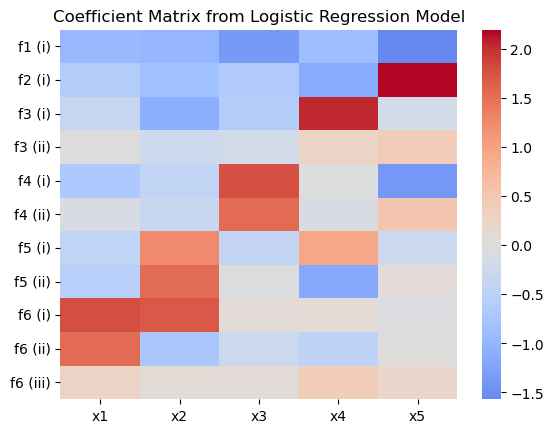

In [10]:
import seaborn as sns

vmax = coef.abs().max().max()
sns.heatmap(coef, cmap='coolwarm', center=0)
plt.title('Coefficient Matrix from Logistic Regression Model')

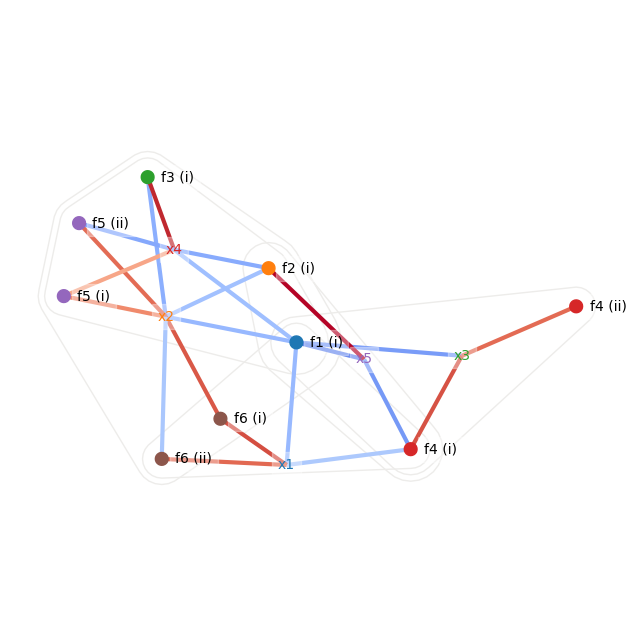

In [66]:
import hypernetx as hnx
import networkx as nx

threshold = 0.65

E = coef.unstack()
E = E[E.abs() > threshold]

H = hnx.Hypergraph(
    E.groupby(level=0)\
        .apply(lambda ser: ser.index.get_level_values(1).tolist())\
        .to_dict()
)

B = H.bipartite()

cmap = plt.cm.coolwarm
vmax = max(-coef.min().min(), coef.max().max())
norm = plt.Normalize(-vmax, vmax)
edge_color=[
    cmap(norm(coef.loc[v, u]))
    for u, v in B.edges()
]

colors = {
    l: plt.cm.tab10(i)
    for i, l in enumerate(labels)
}
node_color = [
    colors[v.split(' ')[0]]
    for v in H.nodes()
]

hnx.draw(
    H,
    nodes_kwargs=dict(color=node_color),
    edges_kwargs=dict(edgecolor=lightgray),
    with_additional_edges=B,
    edge_labels_on_edge=False, contain_hyper_edges=True,
    additional_edges_kwargs=dict(edge_color=edge_color, width=3)
)

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
 (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)]

In [ ]:
self.

In [ ]:
label = self.df[self.left]\
    .rank(ascending=False)\
    .idxmin(axis=1)

In [264]:
self.df[self.left]\
    .rank(ascending=False)\
    .idxmin(axis=1)\
    .to_frame(name='Specialization')

,Specialization
0,f5
1,f6
2,f6
3,f3
4,f1
...,...
95,f2
96,f4
97,f2
98,f4
